In [2]:
import pandas as pd

# Load dataset
data = pd.read_csv("crop_yield_dataset.csv")
data.head()


,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [3]:
import pandas as pd
from category_encoders import LeaveOneOutEncoder

# Load dataset
data = pd.read_csv("crop_yield_dataset.csv")

# Leave-One-Out Encoding for categorical columns
loo_encoder = LeaveOneOutEncoder(cols=['Crop_Type', 'Soil_Type'])
data_loo = loo_encoder.fit_transform(data, data['Crop_Yield'])

print("Leave-One-Out Encoded Data (first 5 rows):")
print(data_loo.head())


Leave-One-Out Encoded Data (first 5 rows):
         Date  Crop_Type  Soil_Type  Soil_pH  Temperature   Humidity  \
0  2014-01-01  25.878583  21.995961     5.50     9.440599  80.000000   
1  2014-01-01  28.309596  36.513692     6.50    20.052576  79.947424   
2  2014-01-01  28.696087  21.995961     5.50    12.143099  80.000000   
3  2014-01-01  25.543701  23.194624     6.75    19.751848  80.000000   
4  2014-01-01  25.930120  21.991435     5.50    16.110395  80.000000   

   Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
0   10.956707  60.5  45.0  31.5    0.000000     22.833333  
1    8.591577  84.0  66.0  50.0  104.871310     66.666667  
2    7.227751  71.5  54.0  38.5    0.000000     27.333333  
3    2.682683  50.0  40.0  30.0   58.939796     35.000000  
4    7.696070  49.5  45.0  38.5   32.970413     22.166667  


In [4]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to scale
num_cols = ['Soil_pH', 'Temperature', 'N', 'P', 'K', 'Crop_Yield', 'Soil_Quality']

# Standard Scaling
scaler_std = StandardScaler()
data_std = data.copy()
data_std[num_cols] = scaler_std.fit_transform(data[num_cols])

print("Standard Scaled Data (first 5 rows):")
print(data_std[num_cols].head())


Standard Scaled Data (first 5 rows):
    Soil_pH  Temperature         N         P         K  Crop_Yield  \
0 -1.349796    -1.611296 -0.506223 -0.909364 -1.231978   -1.044206   
1 -0.125748    -0.421665  1.652399  1.473544  0.934884    3.029956   
2 -1.349796    -1.308338  0.504196  0.111882 -0.412084   -1.044206   
3  0.180264    -0.455378 -1.470714 -1.476722 -1.407669    1.245555   
4 -1.349796    -0.863594 -1.516642 -0.909364 -0.412084    0.236666   

   Soil_Quality  
0     -0.829428  
1      1.646622  
2     -0.575232  
3     -0.142159  
4     -0.867086  


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max Scaling
scaler_mm = MinMaxScaler()
data_minmax = data.copy()
data_minmax[num_cols] = scaler_mm.fit_transform(data[num_cols])

print("Min-Max Scaled Data (first 5 rows):")
print(data_minmax[num_cols].head())


Min-Max Scaled Data (first 5 rows):
   Soil_pH  Temperature         N         P         K  Crop_Yield  \
0      0.0     0.225013  0.336957  0.250000  0.136364    0.000000   
1      0.4     0.408964  0.847826  0.833333  0.696970    0.767097   
2      0.0     0.271859  0.576087  0.500000  0.348485    0.000000   
3      0.5     0.403751  0.108696  0.111111  0.090909    0.431124   
4      0.0     0.340629  0.097826  0.250000  0.348485    0.241167   

   Soil_Quality  
0      0.156314  
1      0.874403  
2      0.230034  
3      0.355631  
4      0.145392  


In [6]:
# One-Hot Encoding
data_onehot = pd.get_dummies(data, columns=['Crop_Type', 'Soil_Type'], drop_first=True, dtype=int)

print("One-Hot Encoded Data (first 5 rows):")
print(data_onehot.head())


One-Hot Encoded Data (first 5 rows):
         Date  Soil_pH  Temperature   Humidity  Wind_Speed     N     P     K  \
0  2014-01-01     5.50     9.440599  80.000000   10.956707  60.5  45.0  31.5   
1  2014-01-01     6.50    20.052576  79.947424    8.591577  84.0  66.0  50.0   
2  2014-01-01     5.50    12.143099  80.000000    7.227751  71.5  54.0  38.5   
3  2014-01-01     6.75    19.751848  80.000000    2.682683  50.0  40.0  30.0   
4  2014-01-01     5.50    16.110395  80.000000    7.696070  49.5  45.0  38.5   

   Crop_Yield  Soil_Quality  ...  Crop_Type_Rice  Crop_Type_Soybean  \
0    0.000000     22.833333  ...               0                  0   
1  104.871310     66.666667  ...               0                  0   
2    0.000000     27.333333  ...               1                  0   
3   58.939796     35.000000  ...               0                  0   
4   32.970413     22.166667  ...               0                  1   

   Crop_Type_Sugarcane  Crop_Type_Sunflower  Crop_Type_

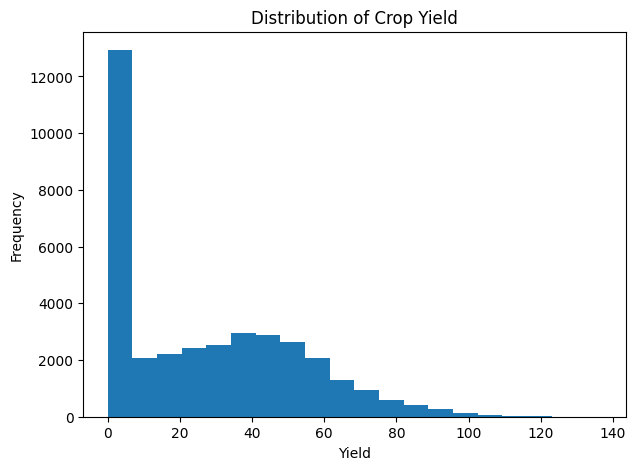

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("crop_yield_dataset.csv")
data.head()

plt.figure(figsize=(7,5))
plt.hist(data['Crop_Yield'], bins=20)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

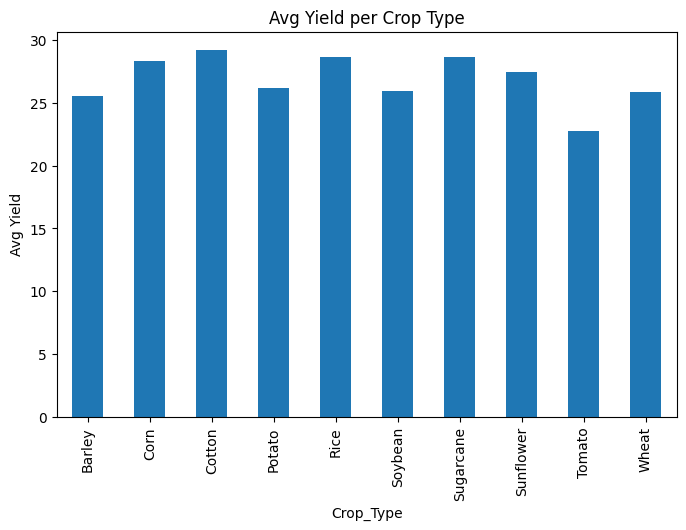

In [8]:
data.groupby('Crop_Type')['Crop_Yield'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Avg Yield per Crop Type")
plt.ylabel("Avg Yield")
plt.show()


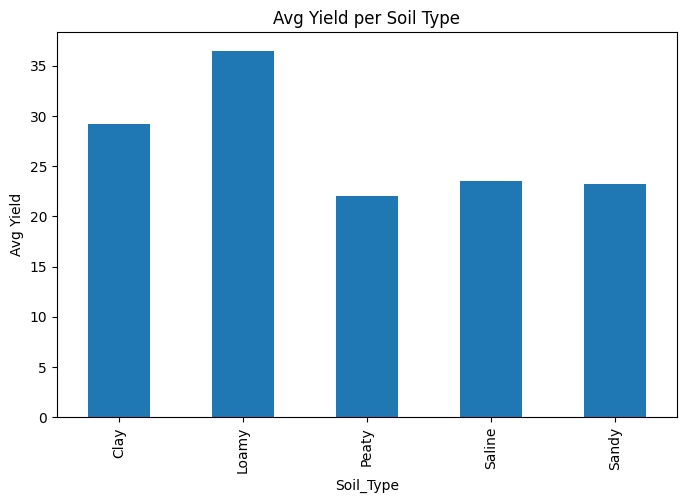

In [9]:
data.groupby('Soil_Type')['Crop_Yield'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Avg Yield per Soil Type")
plt.ylabel("Avg Yield")
plt.show()


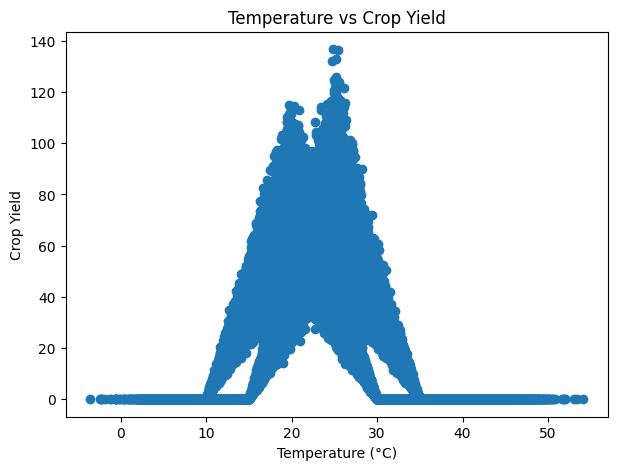

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(data['Temperature'], data['Crop_Yield'])
plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Crop Yield")
plt.show()


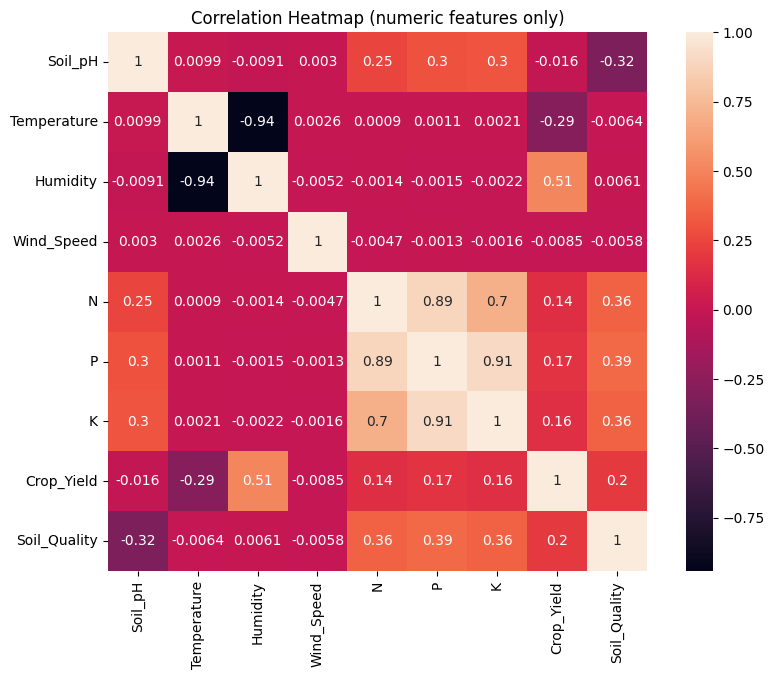

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

num = data.select_dtypes(include='number')

plt.figure(figsize=(10,7))
sns.heatmap(num.corr(), annot=True, square=True)
plt.title("Correlation Heatmap (numeric features only)")
plt.show()



In [5]:

# Label Encoding + MinMax Scaling


import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = pd.read_csv("crop_yield_dataset.csv")
df = df[df["Crop_Yield"] != 0].reset_index(drop=True)

cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["number"]).columns

df_v1 = df.copy()
le = LabelEncoder()

for col in cat_cols:
    df_v1[col] = le.fit_transform(df_v1[col])

scaler = MinMaxScaler()
df_v1[num_cols] = scaler.fit_transform(df_v1[num_cols])

df_v1.to_csv("prep_label_minmax.csv", index=False)
df_v1.head()


,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,0,1,1,0.4,0.402160,0.996494,0.495300,0.847826,0.833333,0.696970,0.767094,0.874403
1,0,0,4,0.5,0.390129,1.000000,0.251013,0.108696,0.111111,0.090909,0.431117,0.355631
2,0,5,2,0.0,0.244445,1.000000,0.458278,0.097826,0.250000,0.348485,0.241157,0.145392
3,0,2,4,0.5,0.193090,1.000000,0.568686,0.217391,0.222222,0.272727,0.214720,0.427304
4,0,8,0,0.3,0.332976,1.000000,0.479032,0.326087,0.250000,0.393939,0.162531,0.475085


In [6]:
#Label Encoding + Standard Scaling


import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("crop_yield_dataset.csv")
df = df[df["Crop_Yield"] != 0].reset_index(drop=True)

cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["number"]).columns

df_v2 = df.copy()
le = LabelEncoder()

for col in cat_cols:
    df_v2[col] = le.fit_transform(df_v2[col])

scaler = StandardScaler()
df_v2[num_cols] = scaler.fit_transform(df_v2[num_cols])

df_v2.to_csv("prep_label_standard.csv", index=False)
df_v2.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,0,1,1,-0.122964,-0.260859,0.802313,-0.469878,1.649420,1.473463,0.936043,2.963444,1.647104
1,0,0,4,0.182886,-0.315545,0.816279,-2.437751,-1.468169,-1.475844,-1.409067,0.912572,-0.141463
2,0,5,2,-1.346363,-0.977727,0.816279,-0.768113,-1.514016,-0.908669,-0.412395,-0.246978,-0.866303
3,0,2,4,0.182886,-1.211154,0.816279,0.121288,-1.009700,-1.022104,-0.705534,-0.408358,0.105642
4,0,8,0,-0.428814,-0.575326,0.816279,-0.600925,-0.551231,-0.908669,-0.236512,-0.726929,0.270378


In [7]:

# One-Hot Encoding + Standard Scaling
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("crop_yield_dataset.csv")
df = df[df["Crop_Yield"] != 0].reset_index(drop=True)

# One-Hot Encode
df_v3 = pd.get_dummies(df, drop_first=True)

# Scale numeric
num_cols = df_v3.select_dtypes(include=["number"]).columns
scaler = StandardScaler()
df_v3[num_cols] = scaler.fit_transform(df_v3[num_cols])

df_v3.to_csv("prep_onehot_standard.csv", index=False)
df_v3.head()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality,Date_2014-01-02,...,Crop_Type_Rice,Crop_Type_Soybean,Crop_Type_Sugarcane,Crop_Type_Sunflower,Crop_Type_Tomato,Crop_Type_Wheat,Soil_Type_Loamy,Soil_Type_Peaty,Soil_Type_Saline,Soil_Type_Sandy
0,-0.122964,-0.260859,0.802313,-0.469878,1.649420,1.473463,0.936043,2.963444,1.647104,False,...,False,False,False,False,False,False,True,False,False,False
1,0.182886,-0.315545,0.816279,-2.437751,-1.468169,-1.475844,-1.409067,0.912572,-0.141463,False,...,False,False,False,False,False,False,False,False,False,True
2,-1.346363,-0.977727,0.816279,-0.768113,-1.514016,-0.908669,-0.412395,-0.246978,-0.866303,False,...,False,True,False,False,False,False,False,True,False,False
3,0.182886,-1.211154,0.816279,0.121288,-1.009700,-1.022104,-0.705534,-0.408358,0.105642,False,...,False,False,False,False,False,False,False,False,False,True
4,-0.428814,-0.575326,0.816279,-0.600925,-0.551231,-0.908669,-0.236512,-0.726929,0.270378,False,...,False,False,False,False,True,False,False,False,False,False


In [8]:

# Leave-One-Out Encoding + MinMax Scaling

import pandas as pd
from category_encoders import LeaveOneOutEncoder
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("crop_yield_dataset.csv")
df = df[df["Crop_Yield"] != 0].reset_index(drop=True)

cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["number"]).columns

df_v4 = df.copy()
loo = LeaveOneOutEncoder(cols=cat_cols)
df_v4 = loo.fit_transform(df_v4, df_v4["Crop_Yield"])

scaler = MinMaxScaler()
df_v4[num_cols] = scaler.fit_transform(df_v4[num_cols])

df_v4.to_csv("prep_loo_minmax.csv", index=False)
df_v4.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,44.311113,40.966442,52.501041,0.4,0.402160,0.996494,0.495300,0.847826,0.833333,0.696970,0.767094,0.874403
1,51.966365,37.007957,33.402460,0.5,0.390129,1.000000,0.251013,0.108696,0.111111,0.090909,0.431117,0.355631
2,56.294596,36.923115,31.327259,0.0,0.244445,1.000000,0.458278,0.097826,0.250000,0.348485,0.241157,0.145392
3,56.896979,41.984588,33.408309,0.5,0.193090,1.000000,0.568686,0.217391,0.222222,0.272727,0.214720,0.427304
4,58.086102,32.445278,41.611338,0.3,0.332976,1.000000,0.479032,0.326087,0.250000,0.393939,0.162531,0.475085


In [1]:
# ============================
# MODEL TRAINING (semi-neat + fast)
# ============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler

datasets = {
    "Label_MinMax": "prep_label_minmax.csv",
    "Label_Standard": "prep_label_standard.csv",
    "OneHot_Standard": "prep_onehot_standard.csv",
    "LOO_MinMax": "prep_loo_minmax.csv"
}

for name, file in datasets.items():
    print("\n=========================")
    print("Training on:", name)
    print("=========================")

    df = pd.read_csv(file)

    y = df["Crop_Yield"]
    X = df.drop("Crop_Yield", axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # RF
    rf = RandomForestRegressor(n_estimators=180, random_state=5)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    print("RF → RMSE:", (mean_squared_error(y_test, pred_rf))**0.5,
          " R2:", r2_score(y_test, pred_rf))

    # XGB
    xgb = XGBRegressor(n_estimators=200, random_state=5, learning_rate=0.1)
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)
    print("XGB → RMSE:", (mean_squared_error(y_test, pred_xgb))**0.5,
          " R2:", r2_score(y_test, pred_xgb))

    # SVR (skip for OneHot dataset)
    if name != "OneHot_Standard":
        scaler = MinMaxScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        svr = SVR(kernel="rbf", C=12, epsilon=0.1)
        svr.fit(X_train_s, y_train)
        pred_svr = svr.predict(X_test_s)

        print("SVR → RMSE:", (mean_squared_error(y_test, pred_svr))**0.5,
              " R2:", r2_score(y_test, pred_svr))
    else:
        print("SVR skipped for OneHot_Standard (dataset too large)")



Training on: Label_MinMax
RF → RMSE: 0.0348543446106653  R2: 0.9550581041670256
XGB → RMSE: 0.03458998268489036  R2: 0.9557372659335793
SVR → RMSE: 0.04889981528543208  R2: 0.9115389715093348

Training on: Label_Standard
RF → RMSE: 0.2127951511445745  R2: 0.9550423474173532
XGB → RMSE: 0.21028146576117918  R2: 0.9560982165995437
SVR → RMSE: 0.2206019096216301  R2: 0.9516831395657284

Training on: OneHot_Standard
RF → RMSE: 0.21119976154150136  R2: 0.9557139426038328
XGB → RMSE: 0.2252703191111452  R2: 0.949616524753736
SVR skipped for OneHot_Standard (dataset too large)

Training on: LOO_MinMax
RF → RMSE: 0.002884967268603857  R2: 0.9996920931664124
XGB → RMSE: 0.009021464931756998  R2: 0.9969891322652705
SVR → RMSE: 0.04454125048165115  R2: 0.926605695690112


In [10]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 5.6 MB/s eta 0:00:13
    --------------------------------------- 1.0/72.0 MB 2.8 MB/s eta 0:00:26
   - -------------------------------------- 1.8/72.0 MB 3.1 MB/s eta 0:00:23
   - -------------------------------------- 2.9/72.0 MB 3.6 MB/s eta 0:00:20
   - -------------------------------------- 3.4/72.0 MB 3.5 MB/s eta 0:00:20
   -- ------------------------------------- 4.2/72.0 MB 3.4 MB/s eta 0:00:20
   -- ------------------------------------- 5.0/72.0 MB 3.4 MB/s eta 0:00:20
   --- ------------------------------------ 5.8/72.0 MB 3.4 MB/s eta 0:00:20
   --- ------------------------------------ 6.6/72.0 MB 3.5 MB/s eta 0:00:19
   ---- ----------------------------------- 7.3/72.0 MB 3.5 MB/s eta 0:00:19
   ---- ----------------------------------- 8.1/72.0 MB 3.5 MB/s eta 0:00:19
   ---- ----------------------------------- 8.9/72.0 MB 3.5 MB/s eta 0:00:18
   ---

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(df['Crop_Yield'], lags=40)
plt.title("ACF - Crop Yield")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['Crop_Yield'], lags=40)
plt.title("PACF - Crop Yield")
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Crop_Yield'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


In [20]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(df['Crop_Yield'], nlags="auto")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])


KPSS Statistic: 0.05443193693556635
p-value: 0.1


C:\Users\Himabindu\AppData\Local\Temp\ipykernel_16040\2009963178.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df['Crop_Yield'], nlags="auto")


In [ ]:
print(df.shape)
print(df['Crop_Yield'].head())
